In [1]:
import pandas as pd
import re
import platform
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import sys
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from utils import *

In [2]:
use_cuda = torch.cuda.is_available()
print(use_cuda)
device = torch.device("cuda")
# to use gpu

True


In [3]:
PROJECT_DIR = '../'            # IMAGE-CAPTIONING-DL

In [4]:
current_cwd = os.getcwd()

In [5]:
if platform.system() == 'Windows':
    lst = current_cwd.split('\\', 2)
    new_cwd = '/'.join(lst[:2])
    os.chdir(new_cwd)
    sys.path.append(new_cwd + '/code')
    IMAGES_PATH = 'data/flickr8k/Images'
    CAPTIONS_PATH = 'data/flickr8k/captions.txt'
    print("IMAGES_PATH (Windows):", IMAGES_PATH)
else:
    IMAGES_PATH = os.path.join('../', 'data', 'flickr8k', 'Images')
    CAPTIONS_PATH = os.path.join('../', 'data', 'flickr8k', 'captions.txt')
    print("IMAGES_PATH (Linux/WSL):", IMAGES_PATH)

IMAGES_PATH (Linux/WSL): ../data/flickr8k/Images


In [6]:
data = pd.read_csv(CAPTIONS_PATH)
data.head(2)

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .


#### 1.Using CNN to extract features from images, this step has been set up in *image_features_extraction* with _Img2Vec_

In [7]:
images_data = data.drop_duplicates(subset=['image'])
# only get 1 name of same image

In [8]:
# Add the path to the feature_extraction directory
sys.path.append(os.path.abspath('../feature_extraction/image_features_extraction'))

# Now you can import Img2Vec
from Img2Vec import Img2Vec

In [9]:
features_image = {}
cnt = 0
img2vec = Img2Vec('vgg16bn')
for img in images_data.image:
    features_image[img] = img2vec.get_vector(IMAGES_PATH + '/' + img)
    cnt += 1
    if cnt % 1000 == 0:
        print(f"Completed {cnt} images")


Completed 1000 images
Completed 2000 images
Completed 3000 images
Completed 4000 images
Completed 5000 images
Completed 6000 images
Completed 7000 images
Completed 8000 images


In [10]:
features_image['1000268201_693b08cb0e.jpg']

tensor([0.0000, 0.0000, 0.4187,  ..., 0.0000, 0.0000, 0.0152])

In [11]:
print(features_image['1000268201_693b08cb0e.jpg'].shape)

torch.Size([4096])


#### 2.Handling Text

In [12]:
with open(os.path.join(PROJECT_DIR,'data','flickr8k', 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()
    
''' Create a dictionary to map 1 image with multiple caps '''    
mapping = {}
for line in tqdm(captions_doc.split('\n')):
    img_and_cap = line.split(',')
    if len(line) < 2:
        continue
    image_id, caption = img_and_cap[0], img_and_cap[1:]
    # convert caption list to string
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    # store the caption
    mapping[image_id].append(caption)
# print(mapping['1000268201_693b08cb0e.jpg'])
# print(len(mapping))

100%|██████████| 40456/40456 [00:00<00:00, 1187885.99it/s]


In [13]:
def clean_and_tokenize(cap):
    # for key, cap_list in mapping.items() 
    # cap = cap.rstrip('.')
    cap = cap.strip('"')
    # tokenize
    cap = cap.split()
    # convert to lower case
    cap = [word.lower() for word in cap]
    # remove tokens with numbers in them
    # cap = [word for word in cap if word.isalpha()]   long-neck be deleted
    cap = [word for word in cap if re.match(r'^[a-zA-Z-]+$', word)]
    cap = '<startseq> ' + ' '.join([word for word in cap if len(word) >0]) + ' <endseq>'
    cap = cap.split()
    return cap
print(clean_and_tokenize('"Long-necked , flying white bird grazes water with black legs ."'))

['<startseq>', 'long-necked', 'flying', 'white', 'bird', 'grazes', 'water', 'with', 'black', 'legs', '<endseq>']


In [14]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)
print(len(all_captions))
all_captions[:6]

40455


['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .',
 'A black dog and a spotted dog are fighting']

In [15]:
import random
random.seed(1)
def train_test_split(mapping, train_ratio=0.85, val_ratio = 0.1, test_ratio = 0.05):
    """Splits a mapping dictionary into training and testing sets.
    Args:
        mapping: The input mapping dictionary.
    Returns:
        A tuple of training, validation and testing mappings.
    """

    image_ids = list(mapping.keys())
    random.shuffle(image_ids)

    num_total_imgs = len(image_ids)
    train_index = int(train_ratio * len(image_ids))
    val_index = int((train_ratio+val_ratio) * len(image_ids))

    train_image_ids = image_ids[:train_index]
    val_image_ids = image_ids[train_index:val_index]
    test_image_ids = image_ids[val_index:]

    train_mapping = {image_id: mapping[image_id] for image_id in train_image_ids}
    val_mapping = {image_id: mapping[image_id] for image_id in val_image_ids}
    test_mapping = {image_id: mapping[image_id] for image_id in test_image_ids}

    return train_mapping, val_mapping, test_mapping
train_mapping, val_mapping, test_mapping = train_test_split(mapping)
print(len(train_mapping), len(val_mapping), len(test_mapping))

6877 809 405


In [16]:
def TrainDescriptionTokens(mapping = train_mapping):
    number_of_train_lines = 0
    train_token_to_occurrences_dict = {}
    
    for image_id, captions in mapping.items():
        for caption in captions:
            # Tokenize the caption using clean_and_tokenize
            
            tokens = clean_and_tokenize(cap= caption)
            # Count the occurrences of each token
            for token in tokens:
                if token in train_token_to_occurrences_dict:
                    train_token_to_occurrences_dict[token] += 1
                else:
                    train_token_to_occurrences_dict[token] = 1
            
            number_of_train_lines += 1
    print(f"TrainDescriptionTokens(): number_of_train_lines = {number_of_train_lines}")
    # with open(os.path.join('../', 'data', 'occurrence_train.txt'), "w") as f:
    #     for token, occurrences in train_token_to_occurrences_dict.items():
    #         f.write(f"{token}\t{occurrences}\n")

    return train_token_to_occurrences_dict
train_token_to_occurrences_dict = TrainDescriptionTokens(train_mapping)
# print(len(train_token_to_occurrences_dict))
# 

TrainDescriptionTokens(): number_of_train_lines = 34385


In [17]:
''' Remove the words that appeared just once '''
print(len(train_token_to_occurrences_dict))
single_occurrence_words = []
for word, occurrences in train_token_to_occurrences_dict.items():
    if occurrences < 2:
        single_occurrence_words.append(word)
for word in single_occurrence_words:
    train_token_to_occurrences_dict.pop(word)
print(len(train_token_to_occurrences_dict))

8215
4842


Sort the words in reverse order of frequency and write our vocabulary

In [18]:
vocabulary_filepath = os.path.join(PROJECT_DIR, 'data', 'vocab.txt')
sorted_tokens = sorted(train_token_to_occurrences_dict.items(), key=lambda x: x[1], reverse=True) 
sorted_tokens = [('<unk>', 0), ('<notset>', 0)] + sorted_tokens

with open(vocabulary_filepath, 'w+') as output_file:
    output_file.write("index,word,frequency\n")
    for index, token in enumerate(sorted_tokens):
        output_file.write("{},{},{}\n".format(index, token[0], token[1]))

In [19]:
def LoadVocabulary(vocabularyFilepath = vocabulary_filepath):
    word_to_index_dict = {}
    index_to_word_dict = {}
    vocabDf = pd.read_csv(vocabularyFilepath)
    for i, row in vocabDf.iterrows():
        index = row['index']
        word = row['word']
        word_to_index_dict[word] = index
        index_to_word_dict[index] = word
    return word_to_index_dict, index_to_word_dict
word_to_index_dict, index_to_word_dict = LoadVocabulary(vocabulary_filepath)


In [20]:
print(word_to_index_dict['<unk>'])
print(word_to_index_dict['<notset>'])
print(word_to_index_dict['<startseq>'])
print(word_to_index_dict['<endseq>'])
print(index_to_word_dict[0])
print(index_to_word_dict[1])
print(index_to_word_dict[3])
print(index_to_word_dict[4])

0
1
3
4
<unk>
<notset>
<startseq>
<endseq>


In [21]:
max_length = max(len(caption.split()) for caption in all_captions)
max_length

37

In [22]:
description_maximum_length = 40

In [23]:
def ConvertTokensListToIndices(tokens, word_to_index_dict, maximum_length):
    ''' Convert all the token of a caption of an image to ârray of occurrence'''
    
    indices = [word_to_index_dict['<notset>']] * maximum_length                # set all the positions to <notset>

    for token_idx, token in enumerate(tokens):
        index = word_to_index_dict.get(token, word_to_index_dict['<unk>']) # If the word is not in the dictionary, fall back to '<unk>'
        indices[token_idx] = index
    # if len(tokens) < maximum_length:
    #     indices[len(tokens)] = word_to_index_dict['<endseq>']
    return indices

pretokenized_descriptions_filepath = os.path.join(PROJECT_DIR, 'data', 'token_describ.csv')

with open(pretokenized_descriptions_filepath, 'w+') as outputFile:
    # Write the header
    outputFile.write("image")
    for wordNdx in range(description_maximum_length):
        outputFile.write(",w{}".format(wordNdx))
    outputFile.write("\n")

    # Loop through the lines of the descriptions file
    with open(CAPTIONS_PATH, 'r') as descriptionsFile:

        for line in descriptionsFile.readlines()[1:]:
            line = line.strip()
            line = line.split(',')
            # print(line)
            image_filename, description = line[0], line[1]
            # Tokenize the description
            tokens = clean_and_tokenize(description)

            # Convert the list of tokens to a list of indices
            indices = ConvertTokensListToIndices(tokens,
                                                 word_to_index_dict,
                                                 description_maximum_length)
            outputFile.write(image_filename)
            for i in range(len(indices)):
                outputFile.write(",{}".format(indices[i]))
            outputFile.write("\n")

In [24]:
tokenized_descriptionsDf = pd.read_csv(pretokenized_descriptions_filepath)
tokenized_descriptionsDf.head(2)
# 1 is notset


,image,w0,w1,w2,w3,w4,w5,w6,w7,w8,...,w30,w31,w32,w33,w34,w35,w36,w37,w38,w39
0,1000268201_693b08cb0e.jpg,3,2,45,5,2,87,174,8,121,...,1,1,1,1,1,1,1,1,1,1
1,1000268201_693b08cb0e.jpg,3,2,20,307,65,2,194,120,4,...,1,1,1,1,1,1,1,1,1,1


##### Create a word embedding with the word2vec (Continuous Bag of Words) algorithm¶
Encoding the words with an arbitrary index from a vocabulary dictionary is easy, but it comes with a cost. To translate this encoding into a tensor form would yield to a one-hot encoding

 It would be advantageous to have an encoding that represents words as numerical vectors that transpose word meaning similarities into vector similarities.

In [25]:
training_description_indices = []
for t in tokenized_descriptionsDf.itertuples():
    filename = t[1]
    if filename in list(train_mapping.keys()):
        training_description_indices.append(list(t[2:]))
print("training_description_indices[0:2] = {}".format(training_description_indices[0:2]))
special_tokens = [word_to_index_dict['<startseq>'], word_to_index_dict['<endseq>'], word_to_index_dict['<unk>'], word_to_index_dict['<notset>']]

def is_only_special_tokens(description_indices):
    #Check if cap just all special tokens
    return all(word_idx in special_tokens for word_idx in description_indices)

# check 
for description_indices in training_description_indices:
    if is_only_special_tokens(description_indices):
        print("Only special tokens: ", description_indices)
        continue  

training_description_indices[0:2] = [[3, 2, 45, 5, 2, 87, 174, 8, 121, 52, 2, 404, 13, 400, 5, 29, 0, 682, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [3, 2, 20, 307, 65, 2, 194, 120, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]


#### 3. Create a dataset class that predict important the words

In [26]:
# context mean x words around important word
class ContextToWordDataset(Dataset):
    def __init__(self,
                 training_descriptions_indices,
                 index_to_word_dict,
                 word_to_index_dict,
                 contextLength):
        self.training_descriptions_indices = training_descriptions_indices
        self.index_to_word_dict = index_to_word_dict
        self.word_to_index_dict = word_to_index_dict
        self.contextLength = contextLength

    def __len__(self):
        return len(self.training_descriptions_indices)

    ''' The method below will return a center word, and several context words around (in indices)'''
    def __getitem__(self, idx):
        # print(self.training_descriptions_indices[idx])
        description_indices = self.training_descriptions_indices[idx]        # get cap but presentation is full of indices from created vocab
        last_acceptable_center_index = len(description_indices) - 1          # prevent the center word is out of bound
        
        if self.word_to_index_dict['<endseq>'] in description_indices:
            for position, index in enumerate(description_indices):
                ## if meet"<endseq>", re define the index of last element
                if index == self.word_to_index_dict['<endseq>']:
                    # print("Last: " , position)
                    last_acceptable_center_index = position
                 
        # randomly select a target word
        # target_idx = random.choice(range(last_acceptable_center_index + 1))
     
        while True:
            target_idx = random.choice(range(last_acceptable_center_index+1))
            # remove noise, <unk> not a good center word
            if (description_indices[target_idx] != self.word_to_index_dict['<unk>']) and\
               (description_indices[target_idx] != self.word_to_index_dict['<startseq>']) and\
               (description_indices[target_idx] != self.word_to_index_dict['<endseq>']):
                break
        
        # print("random: ", target_idx)
        
        context_around_idxs_Tsr =  torch.ones((2 * self.contextLength)).long() * self.word_to_index_dict['<notset>']
        
        running_idx = target_idx - int(self.contextLength)    # maybe negative      
        counter = 0
        # consider all word around target
        while counter < 2 * self.contextLength:
            # print("Running ID: ", running_idx)
            if running_idx != target_idx:
                # prevent index is negative or out of bound
                if running_idx >= 0 and running_idx < len(description_indices):
                    context_around_idxs_Tsr[counter] = description_indices[running_idx]
                counter += 1
            running_idx += 1
        target_center_word_idx = description_indices[target_idx]
        if target_center_word_idx >= len(self.word_to_index_dict):
            raise ValueError(f"Invalid target index: {target_center_word_idx}")
        return context_around_idxs_Tsr,  target_center_word_idx
        

train_dataset = ContextToWordDataset(training_description_indices, index_to_word_dict,
                word_to_index_dict, contextLength=3)

In [27]:
# random.seed(1)
sample_data_0 = train_dataset[0]    # test one cap
sample_words_0 = [index_to_word_dict[i] for i in sample_data_0[0].tolist()]        # change to words through indices
center_word_0 = index_to_word_dict[sample_data_0[1]]
print ("sample_words_0 = {}; center_word_0 = {}".format(sample_words_0, center_word_0))
sample_data_1 = train_dataset[1]
sample_words_1 = [index_to_word_dict[i] for i in sample_data_1[0].tolist()]
center_word_1 = index_to_word_dict[sample_data_1[1]]
print ("sample_words_1 = {}; center_word_1 = {}".format(sample_words_1, center_word_1))

sample_words_0 = ['a', 'child', 'in', 'pink', 'dress', 'is']; center_word_0 = a
sample_words_1 = ['<startseq>', 'a', 'girl', 'into', 'a', 'wooden']; center_word_1 = going


Create model that try to predict important word, base on the contextwords around, this will calculate loss and re-upgrade w,b to get the best w,b

In [28]:
class CenterWordPredictor(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension):    # vocab size = len(word_to_index_dict)
        super(CenterWordPredictor, self).__init__()
        # create an Embedding Layer
        self.embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        # create a Linear layer
        self.decoderLinear = torch.nn.Linear(embedding_dimension, vocabulary_size)           #?

    def forward(self, contextTsr):
        if torch.any(contextTsr >= len(self.embedding.weight)):
            raise ValueError("Index out of bounds in context tensor")
        embedding = self.embedding(contextTsr)  # (N, context_length, embedding_dimension)
        # Average over context words: (N, context_length, embedding_dimension) 
        embedding = torch.mean(embedding, dim=1)
        # -> (N, embedding_dimension): a reprenstative vector for context_tensor
        
        
        # Decoding, weight, bias in this layer will be random, loss function and backpropagate will fix them later
        outputTsr = self.decoderLinear(embedding)   # logit of each word, size (N, vocab_size)
        return outputTsr
vocabulary_size = len(word_to_index_dict)
print(f"Vocabulary size: {vocabulary_size}")
embedding_dimension = 128    
word_embedder = CenterWordPredictor(vocabulary_size, embedding_dimension)
if use_cuda:
    word_embedder = word_embedder.cuda()

Vocabulary size: 4844


In [29]:
random.seed(1)
'''
Model will be trained to predict centerword from context.
Backpropagation to fix the weight, bias in 2 matrices above
'''
word_embedder_parameters = filter(lambda p: p.requires_grad, word_embedder.parameters())
optimizer = torch.optim.Adam(word_embedder_parameters, lr=0.0001)

# logit will be passed to lossFcn, inside will have softmax
lossFcn = nn.CrossEntropyLoss()
train_dataLoader = DataLoader(train_dataset, batch_size=32, shuffle=True) # when call, return one batch dataset

for epoch in range(1, 1000+1):     # put max epoch around 1000
    word_embedder.train()
    loss_sum = 0.0
    number_of_batches = 0        # num batches have been sent
    for (context_around_idxs_Tsr, target_center_word_ndx) in train_dataLoader:
        if number_of_batches % 50 == 0 and number_of_batches > 0:
            print (".", end="", flush=True)
        # print("Max index in context tensor:", torch.max(context_around_idxs_Tsr))
        # print("Vocabulary size:", len(self.embedding.weight))
        if use_cuda:
            context_around_idxs_Tsr = context_around_idxs_Tsr.cuda()
            target_center_word_ndx = target_center_word_ndx.cuda()
            
        predicted_center_word_ndx = word_embedder(context_around_idxs_Tsr)
        # calculating Loss
        optimizer.zero_grad()
        
        # print(predicted_center_word_ndx.shape)  # Should be (N, vocab_size)
        # print(target_center_word_ndx.shape)    # Should be (N,)
        loss = lossFcn(predicted_center_word_ndx, target_center_word_ndx)
        loss.backward()
        
        optimizer.step()    # upgrade weight
        
        loss_sum += loss.item()
        number_of_batches += 1
    train_loss = loss_sum/number_of_batches
    print ("\nepoch {}: train_loss = {}".format(epoch, train_loss))

.....................
epoch 1: train_loss = 7.597903150957684
.....................
epoch 2: train_loss = 6.240082063453142
.....................
epoch 3: train_loss = 5.667483551114104
.....................
epoch 4: train_loss = 5.468031660567882
.....................
epoch 5: train_loss = 5.300874830733898
.....................
epoch 6: train_loss = 5.186159012373103
.....................
epoch 7: train_loss = 5.0809706115722655
.....................
epoch 8: train_loss = 4.994251897723176
.....................
epoch 9: train_loss = 4.956719264762346
.....................
epoch 10: train_loss = 4.894907271806584
.....................
epoch 11: train_loss = 4.808597230024116
.....................
epoch 12: train_loss = 4.794492183507875
.....................
epoch 13: train_loss = 4.739909235710321
.....................
epoch 14: train_loss = 4.682174468373144
.....................
epoch 15: train_loss = 4.6448768276392025
.....................
epoch 16: train_loss = 4.594788929029953

In [30]:
''' Write to a csv file embedding matrix just to see, modify if anything goes incorrectly'''
words2vec_dictionary_filepath = os.path.join(PROJECT_DIR, 'data', 'words2vec.csv')
with open(words2vec_dictionary_filepath, 'w+') as word2vecFile:
    # Write the header
    word2vecFile.write("word")
    for embedding_idx in range(embedding_dimension):
        word2vecFile.write(",e{}".format(embedding_idx))
    word2vecFile.write("\n")


    for index, word in index_to_word_dict.items():
        wordEmbeddingList = word_embedder.embedding.weight[index].tolist()
        word2vecFile.write(word)
        for coef in wordEmbeddingList:
            word2vecFile.write(",{}".format(str(coef)))
        word2vecFile.write("\n")

In [31]:
word2vecDf = pd.read_csv(words2vec_dictionary_filepath)
word_to_embedding_dict = {word2vecDf.iloc[i]['word'] : word2vecDf.loc[i, 'e0': 'e{}'.format(embedding_dimension - 1)].tolist()
                              for i in range(len(word2vecDf))}


In [32]:
print ("word_to_embedding_dict['dog'] = {}".format(word_to_embedding_dict['dog']))
print()
print ("word_to_embedding_dict['dance'] = {}".format(word_to_embedding_dict['dance']))

word_to_embedding_dict['dog'] = [np.float64(-1.782671570777893), np.float64(1.2408475875854492), np.float64(-0.2889696955680847), np.float64(-2.8558928966522217), np.float64(1.164012432098389), np.float64(1.1943234205245972), np.float64(-0.5646596550941467), np.float64(1.8552263975143437), np.float64(-0.3344277441501617), np.float64(-0.3786316215991974), np.float64(-0.9123420715332032), np.float64(-1.0189430713653564), np.float64(0.2746814787387848), np.float64(1.7833784818649292), np.float64(0.0730141922831535), np.float64(-4.603296279907227), np.float64(2.6456031799316406), np.float64(-1.8891009092330933), np.float64(-2.366330862045288), np.float64(-1.890738844871521), np.float64(3.364910125732422), np.float64(-1.5790473222732544), np.float64(-3.7885029315948486), np.float64(2.319566011428833), np.float64(-0.7482559680938721), np.float64(4.419396877288818), np.float64(0.4713247418403625), np.float64(-4.397302627563477), np.float64(0.4135071635246277), np.float64(2.7380874156951904), 

#### 4.Training an LSTM network

In [33]:
'''Get the name of dictionary of filename : {indices of words}'''
def ImageFilenameToTokenizedDescriptionsList(descriptionsDF):
    image_filename_to_tokenized_description = {}
    for i, row in descriptionsDF.iterrows():
        filename = descriptionsDF.iloc[i][0]
        tokenized_description = list(descriptionsDF.iloc[i][1:])
        if filename in image_filename_to_tokenized_description:
            image_filename_to_tokenized_description[filename].append(tokenized_description)
        else:
            image_filename_to_tokenized_description[filename] = [tokenized_description]
    return image_filename_to_tokenized_description

# Create the tokenized descriptions mapping
image_filename_to_tokenized_descriptions_list = ImageFilenameToTokenizedDescriptionsList(tokenized_descriptionsDf)
print(image_filename_to_tokenized_descriptions_list['1002674143_1b742ab4b8.jpg'])


[[np.int64(3), np.int64(2), np.int64(40), np.int64(20), np.int64(186), np.int64(5), np.int64(576), np.int64(108), np.int64(5), np.int64(49), np.int64(13), np.int64(2), np.int64(611), np.int64(1210), np.int64(11), np.int64(63), np.int64(219), np.int64(5), np.int64(2), np.int64(1173), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)], [np.int64(3), np.int64(2), np.int64(40), np.int64(20), np.int64(8), np.int64(51), np.int64(5), np.int64(49), np.int64(13), np.int64(2), np.int64(55), np.int64(611), np.int64(1210), np.int64(4), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), n

Set up dataset first

In [34]:
class CaptionGenerationDataset(Dataset):
    def __init__(self, image_filenames,
                 features_extraction, 
                 image_filename_to_tokenized_descriptions_list,
                 startseq_index, endseq_index, notset_index,
                 vocabulary_size, index_to_word_dict, word_to_embedding_dict):
        self.image_filenames = image_filenames
        self.features_extraction = features_extraction
        self.image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list
        self.startseq_index = startseq_index
        self.endseq_index = endseq_index
        self.notset_index = notset_index
        self.vocabulary_size = vocabulary_size
        self.index_to_word_dict = index_to_word_dict
        self.word_to_embedding_dict = word_to_embedding_dict
    
    def __len__(self):
        return len(self.image_filenames)
    
    ''' Next method will return 3 things of an image
        feature_extraction_Tsr: feature extraction of (idx) image
        embedded_chop_gen_cap_Tsr: tensor of words before chop index in that random cap of the image
        next_word_index: the index of the word being chopped
    '''
    def __getitem__(self, idx):
        if idx >= len(self.image_filenames): 
            raise IndexError("CaptionGenerationDataset.__getitem__(): Index {} is greater than the number of images ({})".format(idx, len(self.image_filenames)))
        
        filename = self.image_filenames[idx]
        feature_extraction_Tsr = self.features_extraction[filename]
        
        # Randomly choose one of the descritions of that image
        
        description = random.choice(self.image_filename_to_tokenized_descriptions_list[filename])                            ####################################error
    
        lastIndex = self.index_endseq(description)
        # chop_index = random.randint(1, lastIndex) # The last index of the chopped description,
                                                  # prevent case last = start or end
        
        # chop_gen_cap = [self.notset_index] * len(description)
        # if chop_index >= 0:
        #     for i in range(chop_index):
        #         chop_gen_cap[i] = description[i]
        
        chop_index = random.randint(0, lastIndex) -1 
        
        chop_gen_cap = [self.notset_index] * len(description)
        if chop_index >= 0:
            for i in range(chop_index+1):
                chop_gen_cap[i] = description[i]
                
        embedding_dimension = len(self.word_to_embedding_dict[ self.index_to_word_dict[0] ])
        embedded_chop_gen_cap_Tsr = torch.zeros(len(description), embedding_dimension)
        for word_posn in range(len(chop_gen_cap)):
            # get that index in gencap, pass to index dict to get word, pass to embedding dict to get num embed
            embedding_word = self.word_to_embedding_dict[ self.index_to_word_dict[chop_gen_cap[word_posn]] ]
            embedded_chop_gen_cap_Tsr[word_posn] = torch.tensor(embedding_word)
        
        next_word_index = description[chop_index + 1]
        
        return (feature_extraction_Tsr, embedded_chop_gen_cap_Tsr), next_word_index
    
        
    def index_endseq(self, description_list):
        foundIndex = -1
        for candidateNdx in range(len(description_list)):
            if description_list[candidateNdx] == self.endseq_index:
                foundIndex = candidateNdx
                break
        if foundIndex == -1:
            return len(description_list) - 1
        else:
            return foundIndex
        

In [35]:
lstm_train_dataset = CaptionGenerationDataset(
        list(train_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_embedding_dict = word_to_embedding_dict
    )
lstm_val_dataset = CaptionGenerationDataset(
        list(val_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_embedding_dict = word_to_embedding_dict
    )
lstm_test_dataset = CaptionGenerationDataset(
        list(test_mapping.keys()),
        features_extraction=features_image,
        image_filename_to_tokenized_descriptions_list = image_filename_to_tokenized_descriptions_list,
        startseq_index = word_to_index_dict['<startseq>'],
        endseq_index = word_to_index_dict['<endseq>'],
        notset_index = word_to_index_dict['<notset>'],
        vocabulary_size = vocabulary_size,
        index_to_word_dict = index_to_word_dict,
        word_to_embedding_dict = word_to_embedding_dict
    )

In [36]:
output_feature_size = 4096
features_image['1000268201_693b08cb0e.jpg'].shape

torch.Size([4096])

Create a Model that gen word for caption

In [37]:
lstm_hidden_dimension = 32
lstm_number_of_layers = 2
dropout_prop = 0.5

In [38]:
class LSTM_fixed_embedding(nn.Module):
    def __init__(self, embedding_dim, lstm_hidden_dim, image_feature_dim,
                 num_lstm_layers,  vocabulary_size, dropout_prop = 0.5):
        super(LSTM_fixed_embedding, self).__init__()
        self.embedding_dim = embedding_dim
        self.dropout = nn.Dropout(dropout_prop)
        self.lstm = nn.LSTM(embedding_dim, lstm_hidden_dim, num_lstm_layers,
                                  batch_first=True)
        
        self.linear = nn.Linear(lstm_hidden_dim + image_feature_dim, vocabulary_size)
        
    '''
    ht is shape(num_layer, batch_size, hidden_size)
    ht[-1] is last layer get last hidden situation
    ''' 
    def forward(self, feature_extraction_Tsr, embedded_chop_gen_cap_Tsr):
        aggregated_h, (ht, ct) = self.lstm(embedded_chop_gen_cap_Tsr)
        # trick to look matrices neater
        combined = torch.cat( (nn.functional.normalize(ht[-1]),
                              nn.functional.normalize(feature_extraction_Tsr)), dim=1)
        
        output_Tsr = self.linear(self.dropout(combined))
        # shape = (batch_size, vocab_size), have logit score for each word in dictionary, not pass softmax yet
        return output_Tsr
    
    def Caption(self, feature_extraction_Tsr, max_length, word_to_embedding_dict, index_to_word_dict, startseq_idx, endseq_idx, use_cuda):
        notset_embedding = word_to_embedding_dict['<notset>']
        embedded_chop_gen_cap_Tsr = torch.zeros((max_length, self.embedding_dim))
        for i in range(max_length):
            embedded_chop_gen_cap_Tsr[i] = torch.tensor(notset_embedding)
        
        running_idx = 0
        caption_words = []
        while running_idx < max_length:
            if use_cuda:
                feature_extraction_Tsr = feature_extraction_Tsr.cuda()
                embedded_chop_gen_cap_Tsr = embedded_chop_gen_cap_Tsr.cuda()
            output_Tsr = self.forward(feature_extraction_Tsr.unsqueeze(0), embedded_chop_gen_cap_Tsr.unsqueeze(0))
            next_word_index = torch.argmax(output_Tsr[0]).item()
            next_word = index_to_word_dict[next_word_index]
            caption_words.append(next_word)
            
            embedded_chop_gen_cap_Tsr[running_idx] = torch.tensor(word_to_embedding_dict[next_word])
            running_idx += 1
            if next_word_index == endseq_idx:
                break
        return caption_words

lstm_model = LSTM_fixed_embedding(
        embedding_dim = embedding_dimension,
        lstm_hidden_dim = lstm_hidden_dimension,
        image_feature_dim = output_feature_size,
        num_lstm_layers = lstm_number_of_layers,
        vocabulary_size = vocabulary_size,
        dropout_prop = dropout_prop
        )


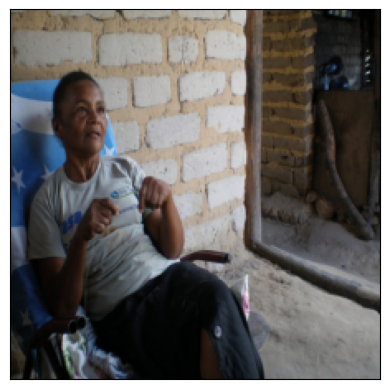

In [39]:
def TestSample(index, validation_images_list, features_image, model,
               index_to_word_dict,
               word_to_embedding_dict,
               sequence_length=40,
               endOfSeqIndex=0,
               use_cuda=True):
    sample_filename = validation_images_list[index]
    sample_feature_extraction_Tsr = torch.FloatTensor(features_image[sample_filename])
    if use_cuda:
        sample_feature_extraction_Tsr = sample_feature_extraction_Tsr.cuda()
    sample_words = model.Caption(
        feature_extraction_Tsr=sample_feature_extraction_Tsr,
        max_length=sequence_length,
        word_to_embedding_dict=word_to_embedding_dict,
        index_to_word_dict=index_to_word_dict,
        startseq_idx = word_to_index_dict['<startseq>'],
        endseq_idx = word_to_index_dict['<endseq>'],
        use_cuda=use_cuda
    )
    return sample_words
validation_sample_0_Ndx = 0
validation_sample_100_Ndx = 100
validation_images_list = list(val_mapping.keys())
img_tensor = readImage(os.path.join(IMAGES_PATH, validation_images_list[validation_sample_0_Ndx]))
show(img_tensor)

In [40]:
best_model_filepath = os.path.join(PROJECT_DIR, 'models', 'lstm.pth')


In [41]:
if use_cuda:
    lstm_model = lstm_model.cuda() 
parameters = filter(lambda p: p.requires_grad, lstm_model.parameters())
optimizer = torch.optim.Adam(parameters, lr=0.0003)
lossFcn = nn.CrossEntropyLoss()
train_dataLoader = DataLoader(lstm_train_dataset, batch_size=16, shuffle=True)
validation_dataLoader = DataLoader(lstm_val_dataset, batch_size=lstm_val_dataset.__len__())

lowestValidationLoss = sys.float_info.max
for epoch in range(1, 1000+1):
    lstm_model.train()
    loss_sum = 0.0
    numberOfBatches = 0
    for ( (feature_extraction_Tsr, embedded_chop_gen_cap_Tsr), next_word_index) in train_dataLoader:
        if numberOfBatches % 4 == 1:
            print (".", end="", flush=True)
        if use_cuda:
            feature_extraction_Tsr = feature_extraction_Tsr.cuda()
            embedded_chop_gen_cap_Tsr = embedded_chop_gen_cap_Tsr.cuda()
            next_word_index = next_word_index.cuda()
        predicted_next_word = lstm_model(feature_extraction_Tsr, embedded_chop_gen_cap_Tsr)
        optimizer.zero_grad()
        loss = lossFcn(predicted_next_word, next_word_index)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        numberOfBatches += 1
    train_loss = loss_sum/numberOfBatches
    print ("\nepoch {}: train_loss = {}".format(epoch, train_loss))

    # Validation
    lstm_model.eval()
    sample_0_words = TestSample(validation_sample_0_Ndx, validation_images_list, features_image, lstm_model,
       index_to_word_dict,
       word_to_embedding_dict,
       sequence_length=40,
       endOfSeqIndex=0,
       use_cuda=use_cuda)
    print ("sample_0_words = {}".format(sample_0_words))
    sample_100_words = TestSample(validation_sample_100_Ndx, validation_images_list, features_image, lstm_model,
       index_to_word_dict,
       word_to_embedding_dict,
       sequence_length=40,
       endOfSeqIndex=0,
       use_cuda=use_cuda)
    print ("sample_100_words = {}".format(sample_100_words))
    
    for ((validation_feature_extraction_Tsr, validation_embedded_chop_gen_cap_Tsr), validation_next_word_index) in validation_dataLoader:
        if use_cuda:
            validation_feature_extraction_Tsr = validation_feature_extraction_Tsr.cuda()
            validation_embedded_chop_gen_cap_Tsr = validation_embedded_chop_gen_cap_Tsr.cuda()
            validation_next_word_index = validation_next_word_index.cuda()
        validation_predicted_next_word = lstm_model(validation_feature_extraction_Tsr, validation_embedded_chop_gen_cap_Tsr)
        validation_loss = lossFcn(validation_predicted_next_word, validation_next_word_index).item()
    print ("validation_loss = {}".format(validation_loss))

    if validation_loss < lowestValidationLoss:
        lowestValidationLoss = validation_loss
        torch.save(lstm_model.state_dict(), best_model_filepath)

............................................................................................................
epoch 1: train_loss = 6.849333514723667
sample_0_words = ['a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']
sample_100_words = ['a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']
validation_loss = 5.538876056671143
............................................................................................................
epoch 2: train_loss = 5.2395174231640125
sample_0_words = ['a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a', 'a']
sample_10

In [42]:
# Load the model that gave the lowest validation loss
lstm_model.load_state_dict(torch.load(best_model_filepath))
# Randomly select some test images
test_image_sample_indices = random.choices(range(len(validation_images_list)), k=3)
lstm_model.eval()
test_sample_filepaths = []
test_sample_captions = []

for test_image_sample_index in test_image_sample_indices:
    sample_words = TestSample(test_image_sample_index, validation_images_list, features_image, lstm_model,
       index_to_word_dict,
       word_to_embedding_dict,
       sequence_length=40,
       endOfSeqIndex=0,
       use_cuda=use_cuda) 
    caption = ' '.join(sample_words)
    test_sample_filepaths.append(os.path.join(IMAGES_PATH, validation_images_list[test_image_sample_index]))
    test_sample_captions.append(caption)

<startseq> a girl in a pink road <endseq>


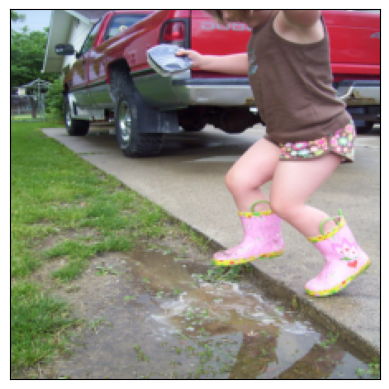

In [43]:
print (test_sample_captions[0])
show(readImage(test_sample_filepaths[0]))

<startseq> a girl in a pool <endseq>


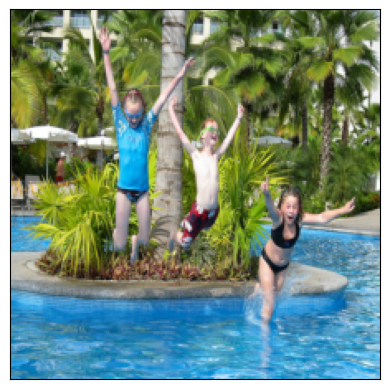

In [44]:
print (test_sample_captions[1])
show(readImage(test_sample_filepaths[1]))

<startseq> a man snowboarding on a slope <endseq>


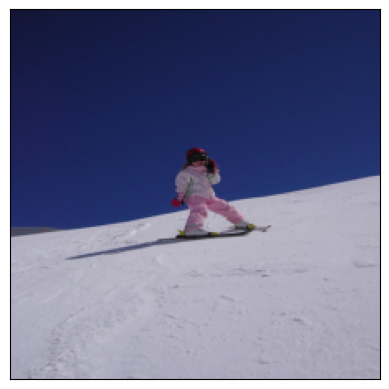

In [45]:
print (test_sample_captions[2])
show(readImage(test_sample_filepaths[2]))
